In [ ]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import figure, show
from numpy import arange
from sklearn import metrics
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Binary Classification
binary_classification_y    = [ 1,    0,   1,   1,    0,    0,    1,    0,    0,    1,   0]
binary_classification_yhat = [ 0.95, 0.1, 0.1, 0.99, 0.98, 0.01, 0.02, 0.01, 0.01, 0.97, 0.05]
binary_classification = pd.DataFrame({'y': binary_classification_y, 'yhat': binary_classification_yhat})
binary_classification

,y,yhat
0,1,0.95
1,0,0.10
2,1,0.10
3,1,0.99
4,0,0.98
5,0,0.01
6,1,0.02
7,0,0.01
8,0,0.01
9,1,0.97


# New Section

In [ ]:
# Multi-class Classification (in this case, 4-class)
multiclass_classification_y    = [ 1, 2, 3, 1, 1, 2, 2, 3, 0, 0, 0]
multiclass_classification_yhat = [
                                    [0.05, 0.00, 0.90, 0.05],
                                    [0.00, 0.01, 0.99, 0.00],
                                    [0.02, 0.00, 0.03, 0.95],
                                    [0.95, 0.03, 0.02, 0.00],
                                    [0.02, 0.94, 0.01, 0.03],
                                    [0.00, 0.00, 0.93, 0.07],
                                    [0.00, 0.20, 0.80, 0.00],
                                    [0.02, 0.02, 0.01, 0.95],
                                    [0.96, 0.04, 0.00, 0.00],
                                    [0.97, 0.01, 0.01, 0.01],
                                    [0.98, 0.00, 0.00, 0.02]
                                 ]
multiclass_classification = pd.DataFrame(multiclass_classification_yhat)
multiclass_classification.insert(loc = 0, column = 'y', value = multiclass_classification_y)
multiclass_classification.columns = ['y', 'yhat_0', 'yhat_1', 'yhat_2', 'yhat_3']
multiclass_classification

,y,yhat_0,yhat_1,yhat_2,yhat_3
0,1,0.05,0.00,0.90,0.05
1,2,0.00,0.01,0.99,0.00
2,3,0.02,0.00,0.03,0.95
3,1,0.95,0.03,0.02,0.00
4,1,0.02,0.94,0.01,0.03
5,2,0.00,0.00,0.93,0.07
6,2,0.00,0.20,0.80,0.00
7,3,0.02,0.02,0.01,0.95
8,0,0.96,0.04,0.00,0.00
9,0,0.97,0.01,0.01,0.01


In [ ]:
# Regression
regression_y    = [ 1.2, 2.2, 3.0, 2.1, 3.5, 3.3, 1.2, 1.2, 0.1, 1, 0.05]
regression_yhat = [ 1.3, 2.9, 3.1, 2.2, 3.5, 3.3, 1.1, 1.3, 7.2, 1, 0.07]
regression = pd.DataFrame({'y': regression_y, 'yhat': regression_yhat})
regression

,y,yhat
0,1.20,1.30
1,2.20,2.90
2,3.00,3.10
3,2.10,2.20
4,3.50,3.50
5,3.30,3.30
6,1.20,1.10
7,1.20,1.30
8,0.10,7.20
9,1.00,1.00


In [ ]:
THRESHOLD = 0.5

y = np.array(binary_classification_y)
y_hat = np.array([(1 if item >= THRESHOLD else 0) for item in binary_classification_yhat])

print(f'binary_classification_y: {binary_classification_y}')
print(f'binary_classification_yhat: {binary_classification_yhat}')
print(f'y: {y}')
print(f'yhat: {y_hat}')

binary_classification_y: [1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0]
binary_classification_yhat: [0.95, 0.1, 0.1, 0.99, 0.98, 0.01, 0.02, 0.01, 0.01, 0.97, 0.05]
y: [1 0 1 1 0 0 1 0 0 1 0]
yhat: [1 0 0 1 1 0 0 0 0 1 0]


In [ ]:
count_pos = sum(y==1)
count_neg = sum(y==0)
count = len(y)
print(f'Positive count: {count_pos}')
print(f'Negatice count: {count_neg}')
print(f'Count: {count}')

tp = sum(np.logical_and(y==1, y_hat==1))
tp_rate = float(tp)/count_pos
tn = sum(np.logical_and(y==0, y_hat==0))
tn_rate = float(tn)/count_neg
fp = sum(np.logical_and(y==0, y_hat==1))
fp_rate = float(fp)/count_neg
fn = sum(np.logical_and(y==1, y_hat==0))
fn_rate = float(fn)/count_pos

print(f'TP = {tp}, TN = {tn}, FP = {fp} and FN = {fn}')
# print(f'TP_rate = {tp_rate}, TN_rate = {tn_rate}, FP_rate = {fp_rate} and FN_rate = {fn_rate}')
print(f'TP_rate = %0.2f, TN_rate = %0.2f, FP_rate = %0.2f and FN_rate = %0.2f'%(tp_rate, tn_rate, fp_rate, fn_rate))
print(f'True Positive Rate (TP, sensitivity): {tp} ({int(tp_rate * 100)}%)')
print(f'True Negative Rate (TN, specificity): {tn} ({int(tn_rate * 100)}%)')
print(f'False Positive Rate (FP): {fp} ({int(fp_rate * 100)}%)')
print(f'False Negative Rate (FN): {fn} ({int(fn_rate * 100)}%)')

Positive count: 5
Negatice count: 6
Count: 11
TP = 3, TN = 5, FP = 1 and FN = 2
TP_rate = 0.60, TN_rate = 0.83, FP_rate = 0.17 and FN_rate = 0.40
True Positive Rate (TP, sensitivity): 3 (60%)
True Negative Rate (TN, specificity): 5 (83%)
False Positive Rate (FP): 1 (16%)
False Negative Rate (FN): 2 (40%)


In [ ]:
ac1 = (tp + tn) / count
ac2 = metrics.accuracy_score(y, y_hat)
print(f"Accuarcy (manual): {ac1}")
print(f"Accuarcy (from sklearn import metrics): {ac2}")

Accuarcy (manual): 0.7272727272727273
Accuarcy (from sklearn import metrics): 0.7272727272727273


In [ ]:
precision = tp / (tp + fp)
precision_sklearn = metrics.precision_score(y, y_hat)

recall = tp / (tp + fn)
recall_sklearn = metrics.recall_score(y, y_hat)

f1 = 2 * (precision * recall) / (precision + recall)
f1_sklearn = metrics.f1_score(y, y_hat)

print(f"recall (manual): {recall}")
print(f"recall (sklearn): {recall_sklearn}")
print(f"precision (manual): {precision}")
print(f"precision (sklearn): {precision_sklearn}")
print(f"f1 (manual): {f1}")
print(f"f1 (sklearn): {f1_sklearn}")

recall (manual): 0.6
recall (sklearn): 0.6
precision (manual): 0.75
precision (sklearn): 0.75
f1 (manual): 0.6666666666666665
f1 (sklearn): 0.6666666666666666


Confusion matrix, without normalization
[[5 1]
 [2 3]]


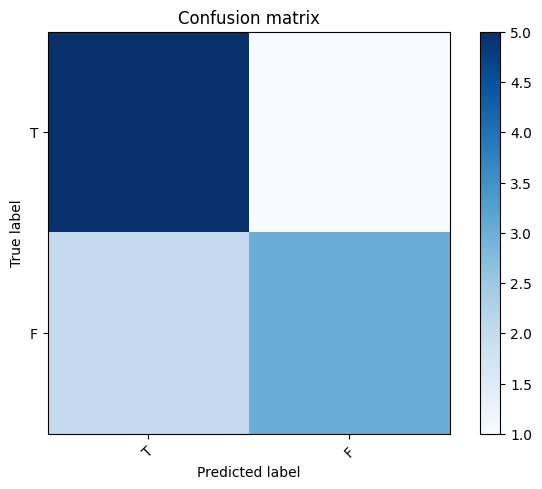

Normalized confusion matrix
[[0.83 0.17]
 [0.4  0.6 ]]


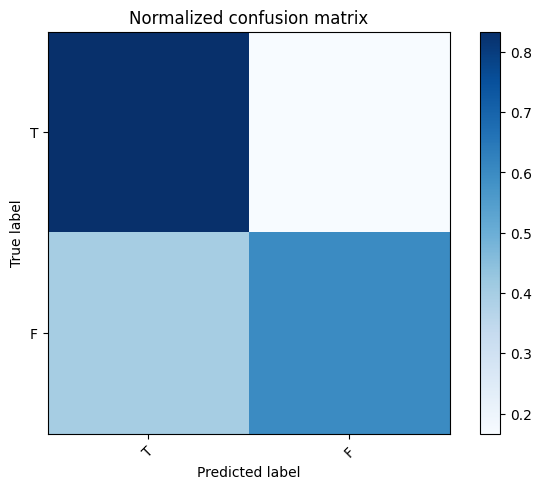

In [ ]:
# Plot a confusion matrix.
# cm is the confusion matrix, names are the names of the classes.
def plot_confusion_matrix(cm, names, title = 'Confusion matrix', cmap = plt.cm.Blues):
    # plt.imshow displays the image on the axes, but if you need to
    # display multiple images you use show() to finish the figure.
    # interpolation = 'none': works well when a big image is scaled down
    # interpolation = 'nearest': works well when a small image is scaled up
    # cmap: The registered colormap name used to map scalar data to colors.
    plt.imshow(cm, interpolation='nearest', cmap = cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(names))
    plt.xticks(tick_marks, names, rotation = 45)
    plt.yticks(tick_marks, names)
    # Automatically adjust subplot parameters to give specified padding.
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
labels = ['T', 'F']

# Compute confusion matrix
cm = confusion_matrix(y, y_hat)
np.set_printoptions(precision = 2)
print('Confusion matrix, without normalization')
print(cm)
plt.figure()
plot_confusion_matrix(cm, labels)
plt.show()

# Normalize the confusion matrix by row
# (i.e. by the number of samples in each class)
cm_normalized = cm.astype('float') / cm.sum(axis = 1)[:, np.newaxis]
print('Normalized confusion matrix')
print(cm_normalized)
plt.figure()
plot_confusion_matrix(cm_normalized, labels, title = 'Normalized confusion matrix')
plt.show()

In [ ]:
multiclass_classification

,y,yhat_0,yhat_1,yhat_2,yhat_3
0,1,0.05,0.00,0.90,0.05
1,2,0.00,0.01,0.99,0.00
2,3,0.02,0.00,0.03,0.95
3,1,0.95,0.03,0.02,0.00
4,1,0.02,0.94,0.01,0.03
5,2,0.00,0.00,0.93,0.07
6,2,0.00,0.20,0.80,0.00
7,3,0.02,0.02,0.01,0.95
8,0,0.96,0.04,0.00,0.00
9,0,0.97,0.01,0.01,0.01


In [ ]:
y = np.array(multiclass_classification_y)
y_hat = np.argmax(multiclass_classification_yhat, axis = 1)

print(f'y: {y}')
print(f'yhat: {y_hat}')

y: [1 2 3 1 1 2 2 3 0 0 0]
yhat: [2 2 3 0 1 2 2 3 0 0 0]


In [ ]:
ac = metrics.accuracy_score(y, y_hat)
# average = None: scores for each class are returned
f1 = metrics.f1_score(y, y_hat, average = None)
print(f"Accuarcy: {ac}")
print(f"F1: {f1}")

Accuarcy: 0.8181818181818182
F1: [0.86 0.5  0.86 1.  ]


Confusion matrix, without normalization
[[3 0 0 0]
 [1 1 1 0]
 [0 0 3 0]
 [0 0 0 2]]


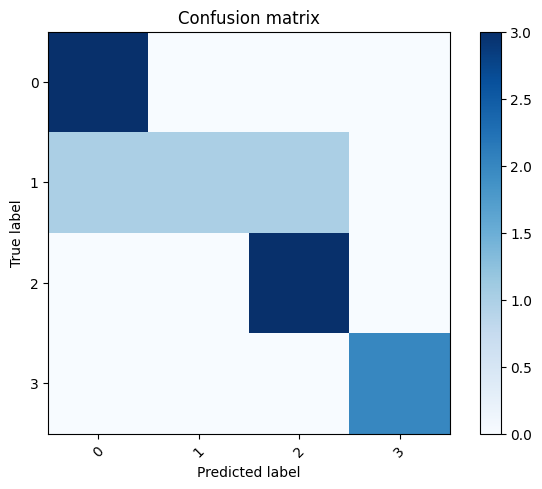

Normalized confusion matrix
[[1.   0.   0.   0.  ]
 [0.33 0.33 0.33 0.  ]
 [0.   0.   1.   0.  ]
 [0.   0.   0.   1.  ]]


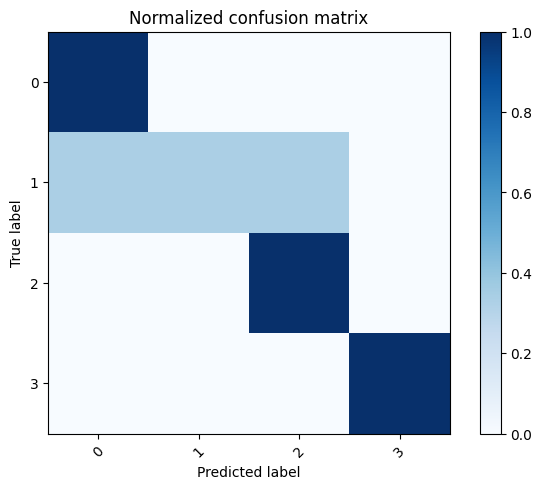

In [ ]:
labels = ['0', '1', '2', '3']

# Compute confusion matrix
cm = confusion_matrix(y, y_hat)
np.set_printoptions(precision = 2)
print('Confusion matrix, without normalization')
print(cm)
plt.figure()
plot_confusion_matrix(cm, labels)
plt.show()

# Normalize the confusion matrix by row (i.e by the number of samples
# in each class)
cm_normalized = cm.astype('float') / cm.sum(axis = 1)[:, np.newaxis]
print('Normalized confusion matrix')
print(cm_normalized)
plt.figure()
plot_confusion_matrix(cm_normalized, labels, title='Normalized confusion matrix')
plt.show()

In [ ]:
y = np.array(binary_classification_y)
y_hat = np.array(binary_classification_yhat)
print (f"y = {y}")
print (f"y_hat = {y_hat}")

y = [1 0 1 1 0 0 1 0 0 1 0]
y_hat = [0.95 0.1  0.1  0.99 0.98 0.01 0.02 0.01 0.01 0.97 0.05]


In [ ]:
# Increase size and add a little noise
np.random.seed(42)
y = np.concatenate([y, y, y, y])
y_hat = np.concatenate([y_hat, y_hat, y_hat, y_hat])
print (y_hat, len(y_hat))
y_hat = y_hat + np.random.normal(size = len(y_hat)) / 10
y_hat = np.clip(y_hat,0.01,0.99)   # values below 0.01 are set to 0.01, and values above 0.99 are set to 0.99
print(y_hat, len(y_hat))

[0.95 0.1  0.1  0.99 0.98 0.01 0.02 0.01 0.01 0.97 0.05 0.95 0.1  0.1
 0.99 0.98 0.01 0.02 0.01 0.01 0.97 0.05 0.95 0.1  0.1  0.99 0.98 0.01
 0.02 0.01 0.01 0.97 0.05 0.95 0.1  0.1  0.99 0.98 0.01 0.02 0.01 0.01
 0.97 0.05] 44
[0.99 0.09 0.16 0.99 0.96 0.01 0.18 0.09 0.01 0.99 0.01 0.9  0.12 0.01
 0.82 0.92 0.01 0.05 0.01 0.01 0.99 0.03 0.96 0.01 0.05 0.99 0.86 0.05
 0.01 0.01 0.01 0.99 0.05 0.84 0.18 0.01 0.99 0.78 0.01 0.04 0.08 0.03
 0.96 0.02] 44


In [ ]:
df = pd.DataFrame({'y':y,'y_hat':y_hat})
df.sort_values(by='y_hat',ascending = False, inplace = True)
df['bucket'] = pd.qcut(range(len(df)), 10, labels = False) + 1
df

,y,y_hat,bucket
0,1,0.990000,1
3,1,0.990000,1
9,1,0.990000,1
25,1,0.990000,1
31,1,0.990000,1
36,1,0.990000,2
20,1,0.990000,2
42,1,0.958435,2
22,1,0.956753,2
4,0,0.956585,3


In [ ]:
df.drop('y_hat', axis=1, inplace=True)
df['count'] = np.ones(len(df))
df = df.groupby(by='bucket').sum()
df

,y,count
bucket,,
1,5,5.0
2,4,4.0
3,1,4.0
4,3,5.0
5,1,4.0
6,1,4.0
7,2,5.0
8,1,4.0
9,0,4.0


In [ ]:
df['score'] = df['y'].values / df['count'].values
df.columns = ['tp','count','score']
df

,tp,count,score
bucket,,,
1,5,5.0,1.00
2,4,4.0,1.00
3,1,4.0,0.25
4,3,5.0,0.60
5,1,4.0,0.25
6,1,4.0,0.25
7,2,5.0,0.40
8,1,4.0,0.25
9,0,4.0,0.00


<Axes: xlabel='bucket'>

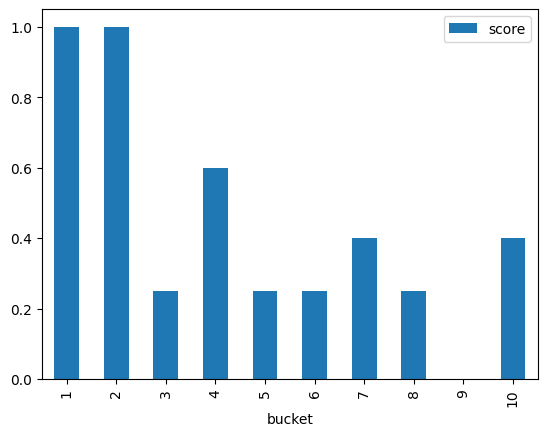

In [ ]:
df.drop('count', axis=1, inplace=True)
df.drop('tp', axis=1, inplace=True)
df.plot(kind = "bar")

In [ ]:
# Regression
regression_y    = [ 1.2, 2.2, 3.0, 2.1, 3.5, 3.3, 1.2, 1.2, 0.1, 1, 0.05]
regression_yhat = [ 1.3, 2.9, 3.1, 2.2, 3.5, 3.3, 1.1, 1.3, 7.2, 1, 0.07]
regression = pd.DataFrame({'y': regression_y, 'yhat': regression_yhat})
regression

,y,yhat
0,1.20,1.30
1,2.20,2.90
2,3.00,3.10
3,2.10,2.20
4,3.50,3.50
5,3.30,3.30
6,1.20,1.10
7,1.20,1.30
8,0.10,7.20
9,1.00,1.00


In [ ]:
y = np.array(regression_y)
y_hat = np.array(regression_yhat)

In [ ]:
# Regression chart.
def chart_regression(pred, y, sort = True):
    t = pd.DataFrame({'pred': pred, 'y': y.flatten()})
    if sort:
        t.sort_values(by=['y'], inplace = True)
    plt.plot(t['y'].tolist(), label = 'expected')
    plt.plot(t['pred'].tolist(), label = 'prediction')
    plt.ylabel('output')
    plt.legend()
    plt.show()

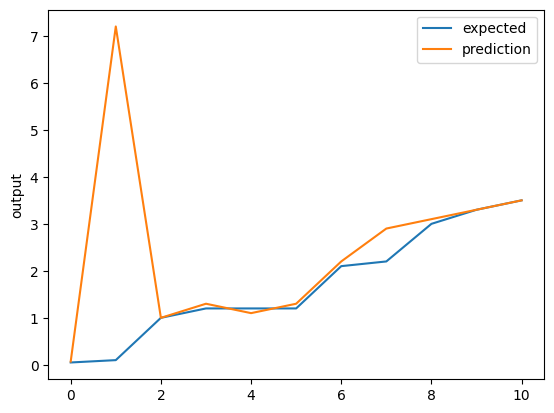

In [ ]:
chart_regression(y_hat, y)

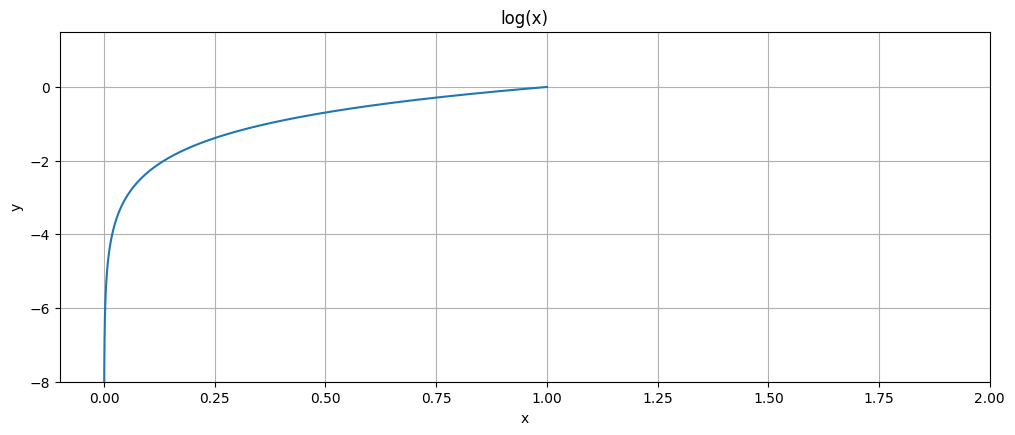

In [ ]:
t = arange(1e-6, 1.0, 0.00001)

fig = figure(1, figsize=(12, 10))

ax1 = fig.add_subplot(211)  # These are subplot grid parameters encoded as a single integer.
                            # Check this link: https://stackoverflow.com/questions/3584805/in-matplotlib-what-does-the-argument-mean-in-fig-add-subplot111
ax1.plot(t, np.log(t))
ax1.grid(True)
ax1.set_ylim((-8, 1.5))
ax1.set_xlim((-0.1, 2))
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('log(x)')

show()

In [ ]:
y = np.array(binary_classification_y)
y_hat = np.array(binary_classification_yhat)

In [ ]:
llos = metrics.log_loss(y, y_hat)
print(f"Log loss: {llos}")

Log loss: 0.9459307962892708


In [ ]:
# What is a good log loss?
print(f"Perfect score (1.0): {np.log(1.0)}")
print(f"95% Prediction on True : {np.log(0.95)}")
print(f"90% Prediction on True : {np.log(0.90)}")
print(f"85% Prediction on True : {np.log(0.85)}")
print(f"80% Prediction on True : {np.log(0.80)}")
print(f"75% Prediction on True : {np.log(0.75)}")
print(f"70% Prediction on True : {np.log(0.70)}")
print(f"65% Prediction on True : {np.log(0.65)}")
print(f"60% Prediction on True : {np.log(0.60)}")
print(f"55% Prediction on True : {np.log(0.55)}")
print(f"40% Prediction on True : {np.log(0.4)}")
print(f"30% Prediction on True : {np.log(0.3)}")
print(f"10% Prediction on True : {np.log(0.1)}")
print(f"1% Prediction on True : {np.log(0.01)}")
print(f"0.001% Prediction on True : {np.log(0.001)}")

Perfect score (1.0): 0.0
95% Prediction on True : -0.05129329438755058
90% Prediction on True : -0.10536051565782628
85% Prediction on True : -0.16251892949777494
80% Prediction on True : -0.2231435513142097
75% Prediction on True : -0.2876820724517809
70% Prediction on True : -0.35667494393873245
65% Prediction on True : -0.4307829160924542
60% Prediction on True : -0.5108256237659907
55% Prediction on True : -0.5978370007556204
40% Prediction on True : -0.916290731874155
30% Prediction on True : -1.2039728043259361
10% Prediction on True : -2.3025850929940455
1% Prediction on True : -4.605170185988091
0.001% Prediction on True : -6.907755278982137


In [ ]:
list(zip(y, y_hat))

[(np.int64(1), np.float64(0.95)),
 (np.int64(0), np.float64(0.1)),
 (np.int64(1), np.float64(0.1)),
 (np.int64(1), np.float64(0.99)),
 (np.int64(0), np.float64(0.98)),
 (np.int64(0), np.float64(0.01)),
 (np.int64(1), np.float64(0.02)),
 (np.int64(0), np.float64(0.01)),
 (np.int64(0), np.float64(0.01)),
 (np.int64(1), np.float64(0.97)),
 (np.int64(0), np.float64(0.05))]

In [ ]:
y = np.array(regression_y)
y_hat = np.array(regression_yhat)
print (y, len(y))
print (y_hat, len(y_hat))

[1.2  2.2  3.   2.1  3.5  3.3  1.2  1.2  0.1  1.   0.05] 11
[1.3  2.9  3.1  2.2  3.5  3.3  1.1  1.3  7.2  1.   0.07] 11


In [ ]:
r2 = metrics.r2_score(y, y_hat)
print(f"R2 Score: {r2}")
print(list(zip(y, y_hat)))

R2 Score: -2.5332034672970853
[(np.float64(1.2), np.float64(1.3)), (np.float64(2.2), np.float64(2.9)), (np.float64(3.0), np.float64(3.1)), (np.float64(2.1), np.float64(2.2)), (np.float64(3.5), np.float64(3.5)), (np.float64(3.3), np.float64(3.3)), (np.float64(1.2), np.float64(1.1)), (np.float64(1.2), np.float64(1.3)), (np.float64(0.1), np.float64(7.2)), (np.float64(1.0), np.float64(1.0)), (np.float64(0.05), np.float64(0.07))]


In [ ]:
y = np.array(regression_y)
y_hat = np.array(regression_yhat)

In [ ]:
mse = metrics.mean_squared_error(y_hat, y)
print("Score (MSE): {}".format(mse))

Score (MSE): 4.631854545454546


In [ ]:
rmse = np.sqrt(mse)
print("Score (RMSE): {}".format(np.sqrt(mse)))

Score (RMSE): 2.1521743761727454
